In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/sample_data/household_power_consumption.txt",
    sep=';',
    parse_dates={'datetime': ['Date', 'Time']},
    infer_datetime_format=True,
    na_values=['?', 'NA', ''],
    low_memory=False
)

df.set_index('datetime', inplace=True)


/tmp/ipython-input-871020990.py:3: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(
/tmp/ipython-input-871020990.py:3: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(
/tmp/ipython-input-871020990.py:3: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(


In [ ]:
df = df.apply(pd.to_numeric, errors='coerce')

In [ ]:
df.info()
df.head()
df.describe()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


In [ ]:
df.isna().sum()


,0
Global_active_power,25979
Global_reactive_power,25979
Voltage,25979
Global_intensity,25979
Sub_metering_1,25979
Sub_metering_2,25979
Sub_metering_3,25979


In [ ]:
df_res = df.resample('H').mean()
df_res.isna().sum()


/tmp/ipython-input-3984273327.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_res = df.resample('H').mean()


,0
Global_active_power,421
Global_reactive_power,421
Voltage,421
Global_intensity,421
Sub_metering_1,421
Sub_metering_2,421
Sub_metering_3,421


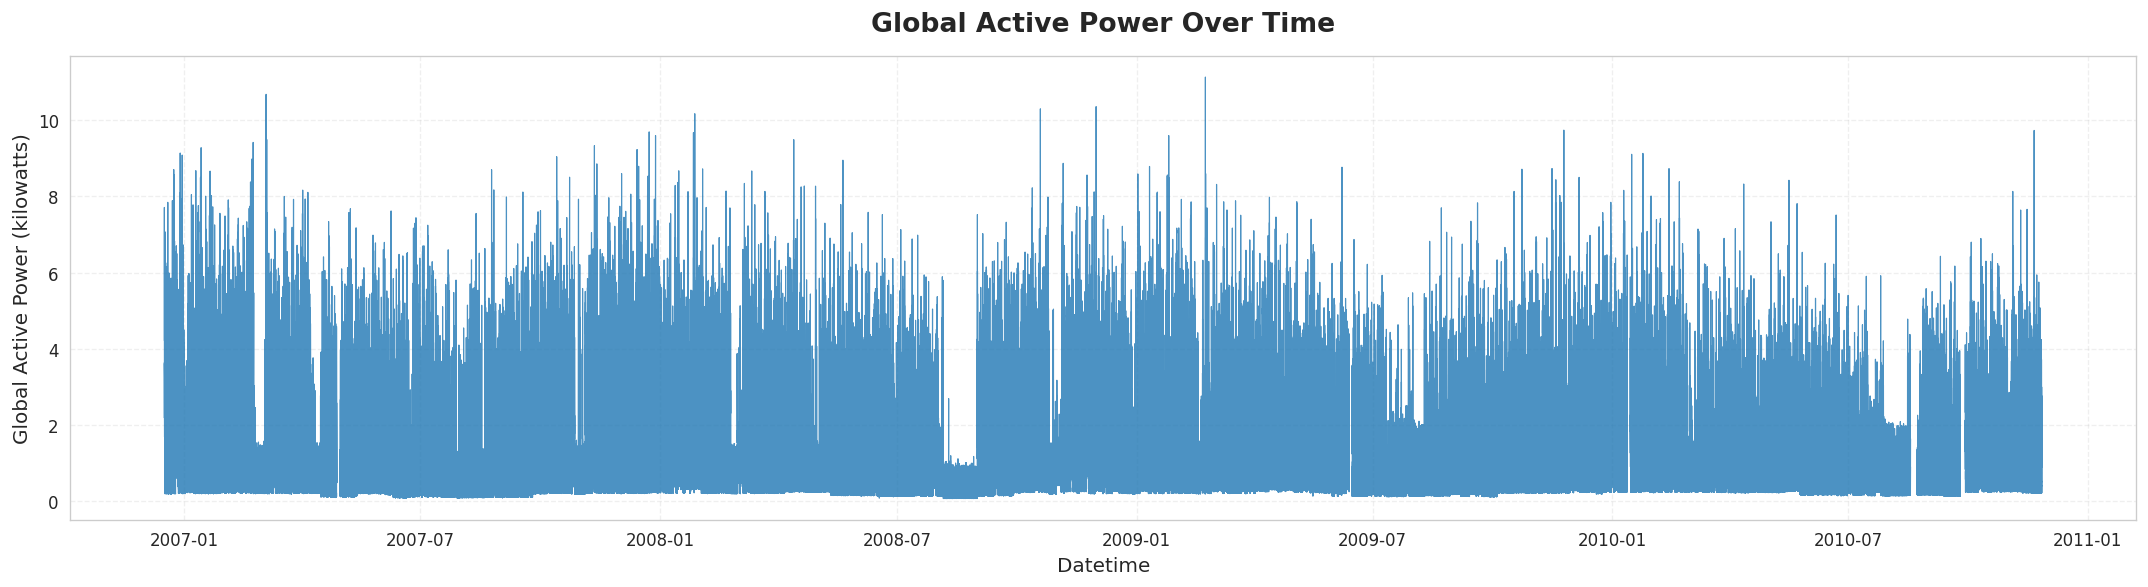

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(18,5), dpi=120)

plt.plot(df.index, df['Global_active_power'],
         linewidth=0.7,
         alpha=0.8,
         color='#1f77b4')

plt.title('Global Active Power Over Time',
          fontsize=16, fontweight='bold', pad=15)

plt.xlabel('Datetime', fontsize=12)
plt.ylabel('Global Active Power (kilowatts)', fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

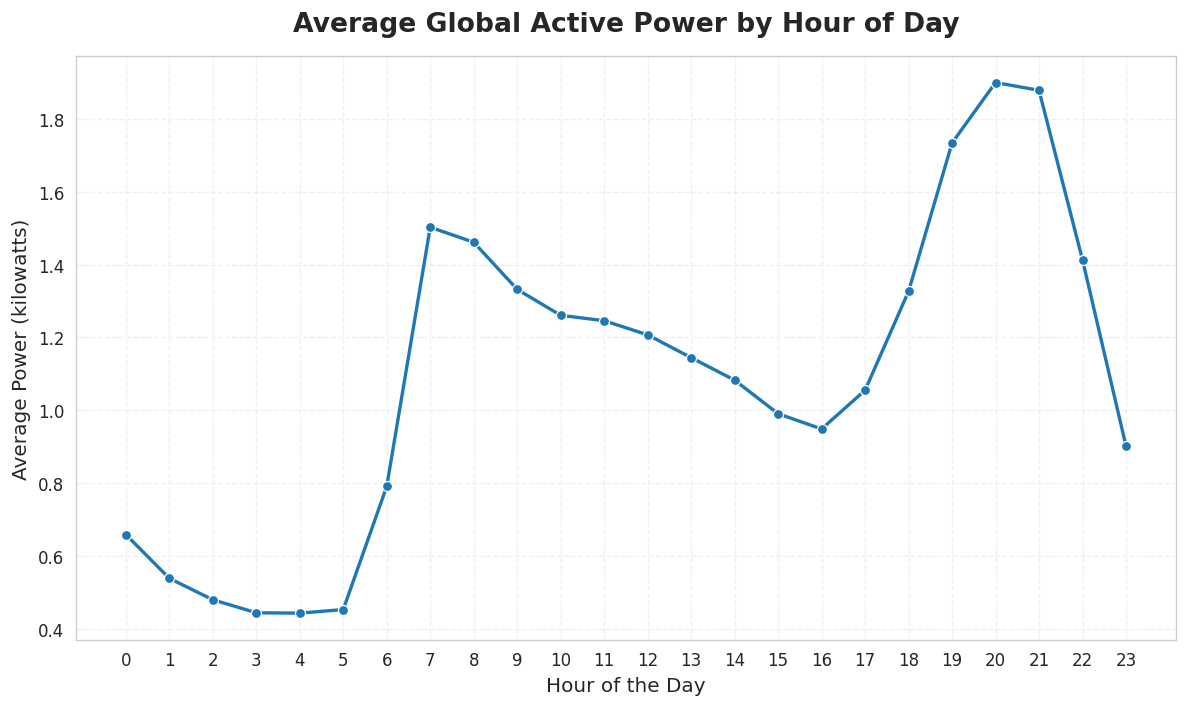

In [ ]:
import seaborn as sns
sns.set_style("whitegrid")

hourly_avg = df.groupby(df.index.hour)['Global_active_power'].mean()

plt.figure(figsize=(10,6), dpi=120)

sns.lineplot(x=hourly_avg.index, y=hourly_avg.values,
             linewidth=2, marker='o', markersize=6)

plt.title("Average Global Active Power by Hour of Day",
          fontsize=16, fontweight='bold', pad=15)

plt.xlabel("Hour of the Day", fontsize=12)
plt.ylabel("Average Power (kilowatts)", fontsize=12)

plt.xticks(range(0, 24), fontsize=10)
plt.yticks(fontsize=10)

plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()



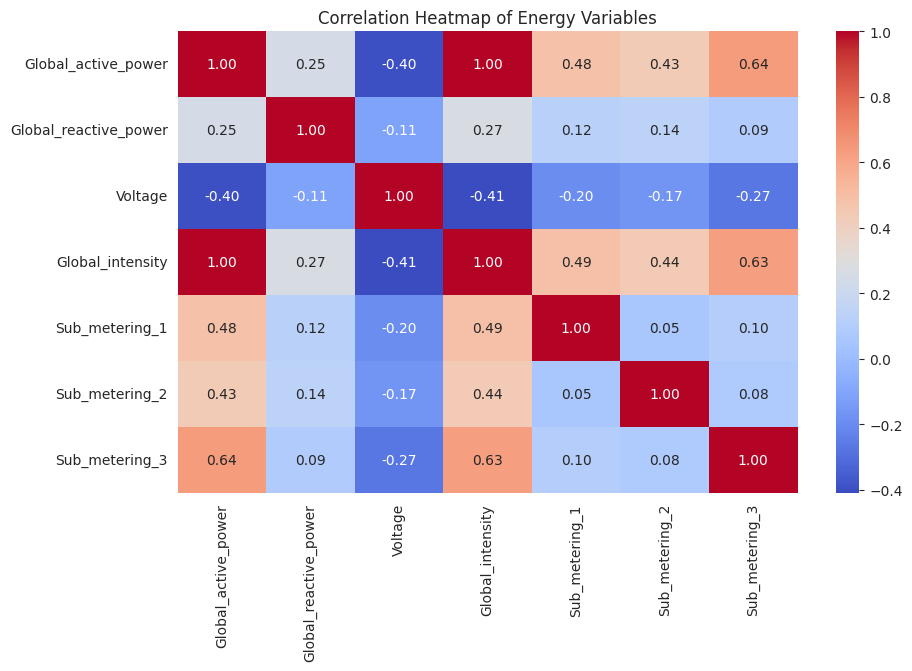

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Energy Variables")
plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


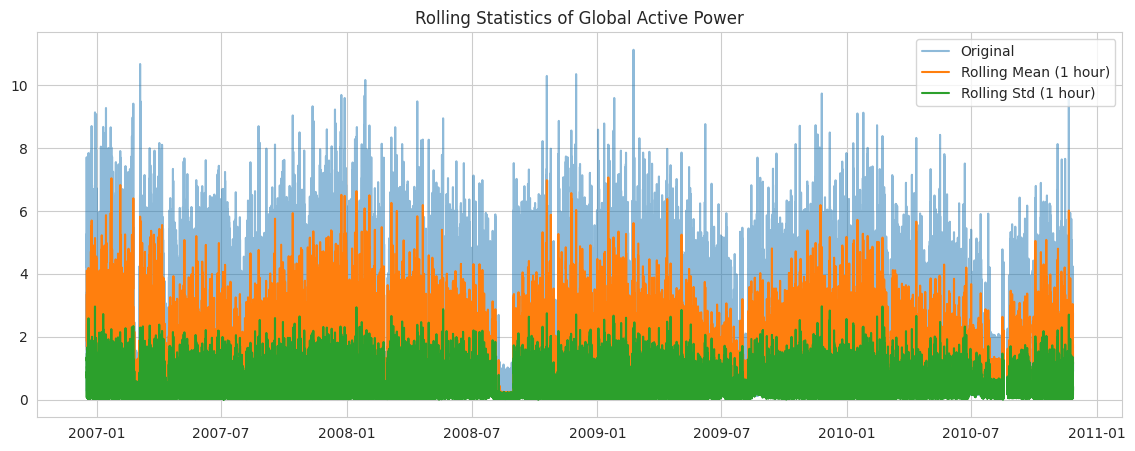

In [ ]:
# Rolling Mean & Rolling Std (Trend Analysis)
df['rolling_mean'] = df['Global_active_power'].rolling(window=60).mean()
df['rolling_std'] = df['Global_active_power'].rolling(window=60).std()

plt.figure(figsize=(14,5))
plt.plot(df['Global_active_power'], label='Original', alpha=0.5)
plt.plot(df['rolling_mean'], label='Rolling Mean (1 hour)')
plt.plot(df['rolling_std'], label='Rolling Std (1 hour)')
plt.title("Rolling Statistics of Global Active Power")
plt.legend()
plt.show()


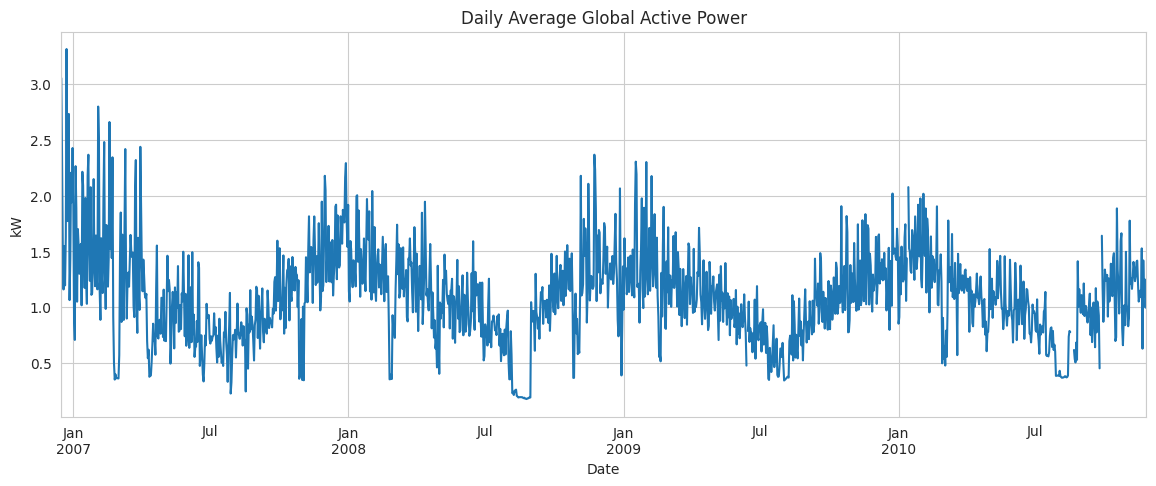

In [ ]:
# Daily Trend
daily_usage = df['Global_active_power'].resample('D').mean()

plt.figure(figsize=(14,5))
daily_usage.plot()
plt.title("Daily Average Global Active Power")
plt.xlabel("Date")
plt.ylabel("kW")
plt.show()


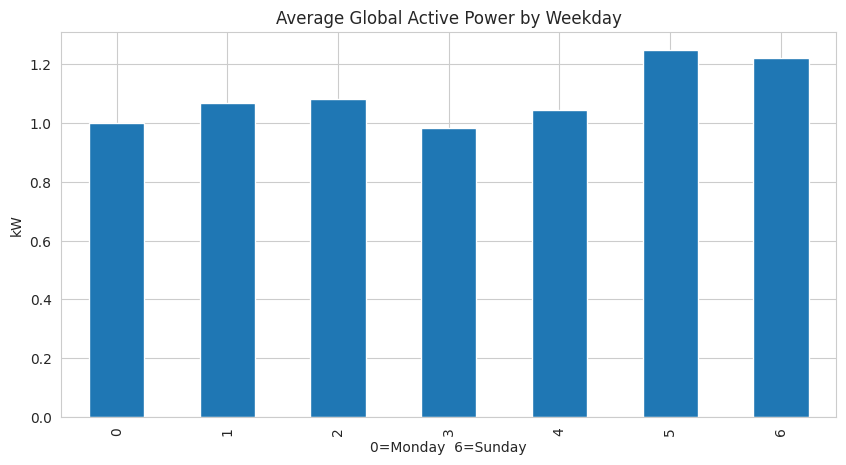

In [ ]:
# Weekly Pattern (Average By Hour)
df['weekday'] = df.index.weekday
weekly_pattern = df.groupby('weekday')['Global_active_power'].mean()

plt.figure(figsize=(10,5))
weekly_pattern.plot(kind='bar')
plt.title("Average Global Active Power by Weekday")
plt.xlabel("0=Monday  6=Sunday")
plt.ylabel("kW")
plt.show()


In [ ]:
df['Global_active_power'].isna().sum()


np.int64(25979)

In [ ]:
# Interpolate missing values
df['Global_active_power'] = df['Global_active_power'].interpolate(method='time')

# Drop any remaining NA
clean_series = df['Global_active_power'].dropna()

np.int64(0)

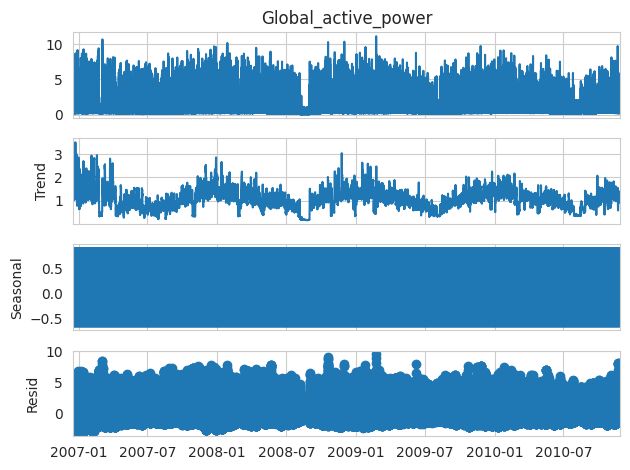

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(df['Global_active_power'], model='additive', period=1440)
decomp.plot()
plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


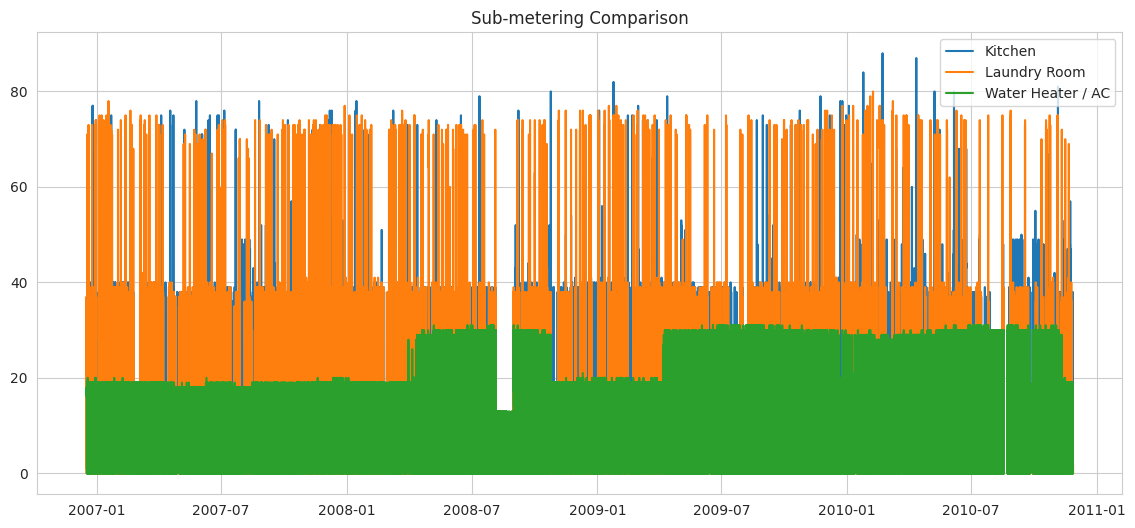

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(df['Sub_metering_1'], label='Kitchen')
plt.plot(df['Sub_metering_2'], label='Laundry Room')
plt.plot(df['Sub_metering_3'], label='Water Heater / AC')
plt.title("Sub-metering Comparison")
plt.legend()
plt.show()


Feature Engineering

In [ ]:
df_hourly = df.resample('H').mean().interpolate()


/tmp/ipython-input-2566615623.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').mean().interpolate()


In [ ]:
df_hourly['hour'] = df_hourly.index.hour
df_hourly['day'] = df_hourly.index.day
df_hourly['weekday'] = df_hourly.index.weekday
df_hourly['month'] = df_hourly.index.month
df_hourly['year'] = df_hourly.index.year


In [ ]:
df_hourly['lag_1'] = df_hourly['Global_active_power'].shift(1)
df_hourly['lag_2'] = df_hourly['Global_active_power'].shift(2)
df_hourly['lag_24'] = df_hourly['Global_active_power'].shift(24)   # same hour previous day
df_hourly['lag_168'] = df_hourly['Global_active_power'].shift(168) # same hour previous week


In [ ]:
df_hourly['rolling_3'] = df_hourly['Global_active_power'].rolling(window=3).mean()
df_hourly['rolling_6'] = df_hourly['Global_active_power'].rolling(window=6).mean()
df_hourly['rolling_24'] = df_hourly['Global_active_power'].rolling(window=24).mean()
df_hourly['rolling_std_24'] = df_hourly['Global_active_power'].rolling(window=24).std()


In [ ]:
df_hourly = df_hourly.dropna()


In [ ]:
target = 'Global_active_power'

features = [
    'hour','day','weekday','month','year',
    'lag_1','lag_2','lag_24','lag_168',
    'rolling_3','rolling_6','rolling_24','rolling_std_24'
]


In [ ]:
from sklearn.model_selection import train_test_split

X = df_hourly[features]
y = df_hourly[target]

# 80% train, 20% test
split_index = int(len(df_hourly)*0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]


In [ ]:
df_hourly.columns


Index(['Global_active_power', 'Global_reactive_power', 'Voltage',
       'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3', 'rolling_mean', 'rolling_std', 'weekday', 'hour',
       'day', 'month', 'year', 'lag_1', 'lag_2', 'lag_24', 'lag_168',
       'rolling_3', 'rolling_6', 'rolling_24', 'rolling_std_24'],
      dtype='object')

In [ ]:
df_hourly.head()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,rolling_mean,rolling_std,weekday,...,month,year,lag_1,lag_2,lag_24,lag_168,rolling_3,rolling_6,rolling_24,rolling_std_24
datetime,,,,,,,,,,,,,,,,,,,,,
2006-12-23 17:00:00,5.452533,0.215967,233.644167,23.360000,16.183333,0.666667,16.750000,4.892125,1.179559,5,...,12,2006,4.349100,4.049100,1.496800,4.222889,4.616911,3.990633,3.099713,1.066674
2006-12-23 18:00:00,3.879400,0.099767,238.000500,16.363333,0.000000,0.016667,17.350000,4.569664,1.336106,5,...,12,2006,5.452533,4.349100,2.686967,3.632200,4.560344,4.149067,3.149397,1.074356
2006-12-23 19:00:00,4.117833,0.205333,238.729333,17.300000,0.000000,0.600000,17.466667,4.203023,0.858574,5,...,12,2006,3.879400,5.452533,3.938167,3.400233,4.483256,4.267656,3.156883,1.080699
2006-12-23 20:00:00,4.181400,0.124767,238.518833,17.596667,0.000000,0.350000,17.416667,4.108088,0.858605,5,...,12,2006,4.117833,3.879400,3.536067,3.268567,4.059544,4.338228,3.183772,1.098426
2006-12-23 21:00:00,3.288433,0.235767,238.594667,13.893333,0.000000,0.216667,5.666667,3.716342,0.912366,5,...,12,2006,4.181400,4.117833,4.548667,3.056467,3.862556,4.211450,3.131263,1.059784


Modeling for 1 week

In [ ]:
df_hourly.index.freq


<Hour>

In [ ]:
df_hourly['Global_active_power'].tail()


,Global_active_power
datetime,
2010-11-26 17:00:00,1.725900
2010-11-26 18:00:00,1.573467
2010-11-26 19:00:00,1.659333
2010-11-26 20:00:00,1.163700
2010-11-26 21:00:00,0.934667


In [ ]:
from sklearn.model_selection import train_test_split

features = [
    'hour','day','weekday','month','year',
    'lag_1','lag_2','lag_24','lag_168',
    'rolling_3','rolling_6','rolling_24','rolling_std_24'
]

X = df_hourly[features]
y = df_hourly['Global_active_power']

# Time-based split
split_index = int(len(df_hourly)*0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=12,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


RandomForestRegressor(max_depth=12, n_estimators=300, n_jobs=-1,
                      random_state=42)

In [ ]:
import pandas as pd

# Start point = last timestamp in your dataset
last_timestamp = df_hourly.index[-1]

future_predictions = []
current_df = df_hourly.copy()

for i in range(168):  # 168 hours = 7 days
    # Set next timestamp
    next_time = last_timestamp + pd.Timedelta(hours=i+1)

    # Build next feature row
    row = {
        'hour': next_time.hour,
        'day': next_time.day,
        'weekday': next_time.weekday(),
        'month': next_time.month,
        'year': next_time.year,
        'lag_1': current_df['Global_active_power'].iloc[-1],
        'lag_2': current_df['Global_active_power'].iloc[-2],
        'lag_24': current_df['Global_active_power'].iloc[-24],
        'lag_168': current_df['Global_active_power'].iloc[-168],
        'rolling_3': current_df['Global_active_power'].iloc[-3:].mean(),
        'rolling_6': current_df['Global_active_power'].iloc[-6:].mean(),
        'rolling_24': current_df['Global_active_power'].iloc[-24:].mean(),
        'rolling_std_24': current_df['Global_active_power'].iloc[-24:].std(),
    }

    # Convert to DataFrame
    row_df = pd.DataFrame([row])

    # Predict next value
    next_pred = rf_model.predict(row_df)[0]
    future_predictions.append(next_pred)

    # Append predicted value to df
    new_row = pd.DataFrame(
        {'Global_active_power': next_pred},
        index=[next_time]
    )
    current_df = pd.concat([current_df, new_row])


In [ ]:
future_index = pd.date_range(
    start=df_hourly.index[-1] + pd.Timedelta(hours=1),
    periods=168,
    freq='H'
)

forecast_df = pd.DataFrame({
    'Forecast_RF': future_predictions
}, index=future_index)

forecast_df.head()


/tmp/ipython-input-4198014508.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_index = pd.date_range(


,Forecast_RF
2010-11-26 22:00:00,1.620768
2010-11-26 23:00:00,1.280140
2010-11-27 00:00:00,0.966436
2010-11-27 01:00:00,1.536221
2010-11-27 02:00:00,1.351157


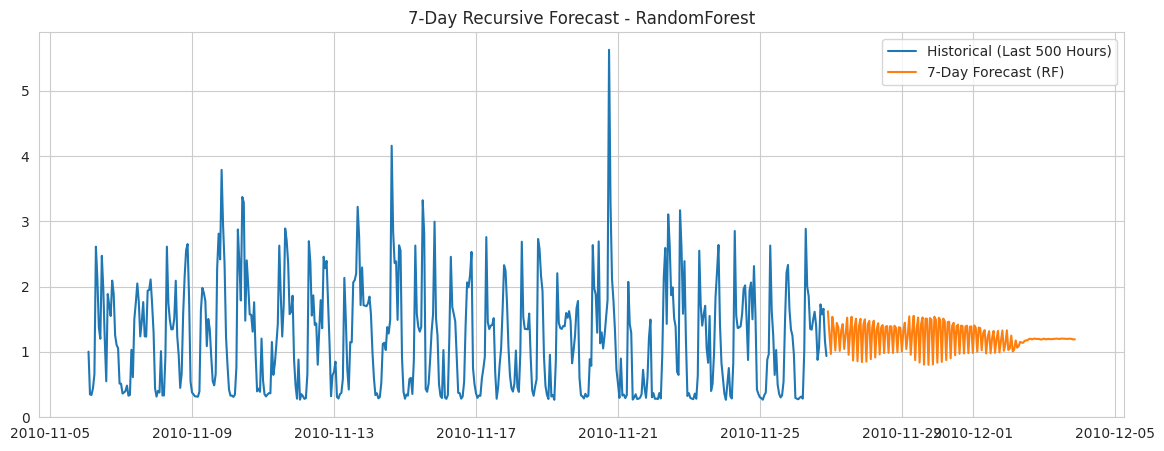

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(df_hourly['Global_active_power'].tail(500), label='Historical (Last 500 Hours)')
plt.plot(forecast_df['Forecast_RF'], label='7-Day Forecast (RF)')

plt.title("7-Day Recursive Forecast - RandomForest")
plt.legend()
plt.show()
